# 9 图论

## 9.1 岛屿数量

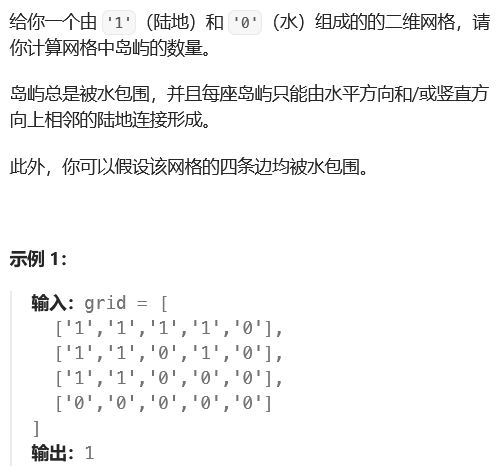

In [ ]:
from typing import List

class Solution:
    def numIslands(self, grid: List[List[str]]) -> int:
        # 空网格边界判断
        if not grid or not grid[0]:
            return 0
        
        rows = len(grid)
        cols = len(grid[0])
        count = 0

        def dfs(r: int, c: int):
            # 递归终止条件：越界 或 当前不是陆地
            if r < 0 or r >= rows or c < 0 or c >= cols or grid[r][c] == '0':
                return
            # 标记为已访问（置为0）
            grid[r][c] = '0'
            # 上下左右四个方向递归搜索
            dfs(r - 1, c)  # 上
            dfs(r + 1, c)  # 下
            dfs(r, c - 1)  # 左
            dfs(r, c + 1)  # 右

        # 遍历整个网格
        for i in range(rows):
            for j in range(cols):
                # 发现新岛屿
                if grid[i][j] == '1':
                    count += 1
                    dfs(i, j)
        return count

## 9.2 腐烂的橘子

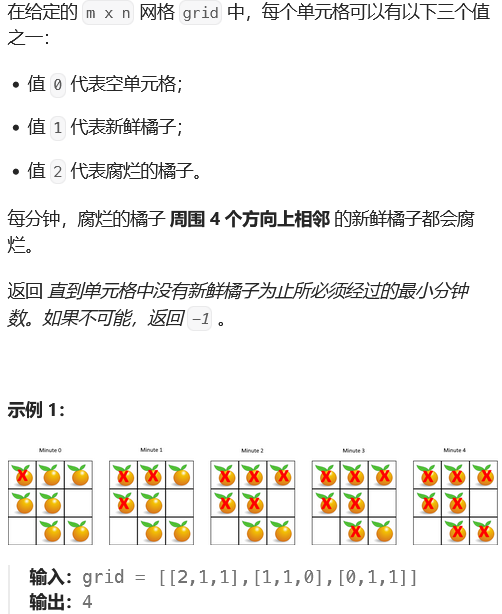

In [ ]:
class Solution:
    def orangesRotting(self, grid: List[List[int]]) -> int:
        from collections import deque
        m = len(grid)
        n = len(grid[0])
        q = deque()
        fresh = 0
        # 方向数组：上下左右
        dirs = [(-1,0), (1,0), (0,-1), (0,1)]
        
        # 第一步：遍历网格，收集烂橘子、统计新鲜橘子
        for i in range(m):
            for j in range(n):
                if grid[i][j] == 2:
                    q.append((i, j))
                elif grid[i][j] == 1:
                    fresh += 1
        
        time = 0
        # BFS分层遍历
        while q and fresh > 0:
            # 当前层所有烂橘子同时扩散，一层=1分钟
            layer_size = len(q)
            for _ in range(layer_size):
                x, y = q.popleft()
                # 四个方向扩散
                for dx, dy in dirs:
                    nx = x + dx
                    ny = y + dy
                    # 边界合法 + 是新鲜橘子
                    if 0 <= nx < m and 0 <= ny < n and grid[nx][ny] == 1:
                        grid[nx][ny] = 2  # 腐烂
                        fresh -= 1
                        q.append((nx, ny))
            time += 1  # 一层扩散完成，时间+1
        
        return time if fresh == 0 else -1

## 9.3 课程表

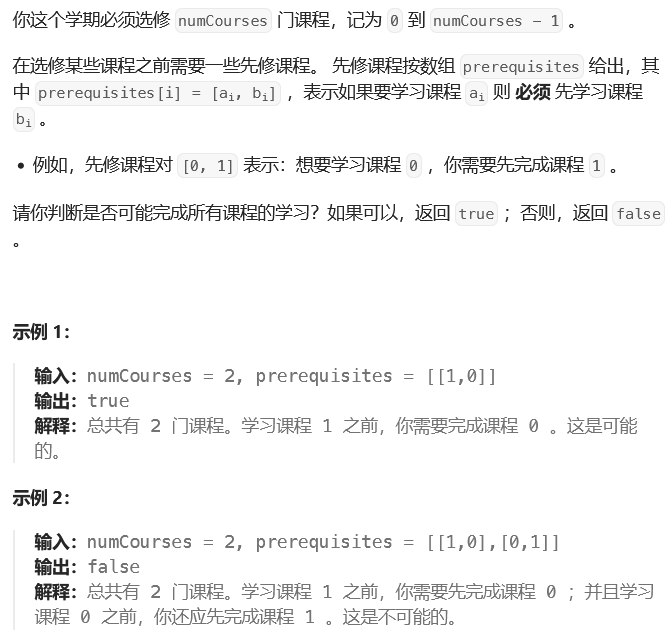

In [ ]:
class Solution:
    def canFinish(self, numCourses: int, prerequisites: List[List[int]]) -> bool:
        from collections import deque
        # 1. 构建邻接表 & 入度数组
        # adj[i] 存储所有以课程 i 为先修课的后续课程，即有向边 i→x 的全部 x 集合。
        adj = [[] for _ in range(numCourses)]
        # in_degree[i] : 课程 i 需要先修的课程总数量。
        # 入度为 0 = 所有前置都学完了，现在能学。
        in_degree = [0] * numCourses
        for cur, pre in prerequisites:
            adj[pre].append(cur)
            in_degree[cur] += 1
        
        q = deque()
        # 入度为0的节点入队
        for i in range(numCourses):
            if in_degree[i] == 0:
                q.append(i)
        
        count = 0
        while q:
            node = q.popleft()
            count += 1
            # 遍历后继
            for nxt in adj[node]:
                # node 是 nxt 的一门前置课，现在 node 已经学完，nxt 还差的前置课程数量减 1
                in_degree[nxt] -= 1
                if in_degree[nxt] == 0:
                    # nxt 的所有前置课都学完了，现在可以学了
                    q.append(nxt)
        # 遍历所有节点说明无环
        return count == numCourses

## 9.4 实现Trie (前缀树)

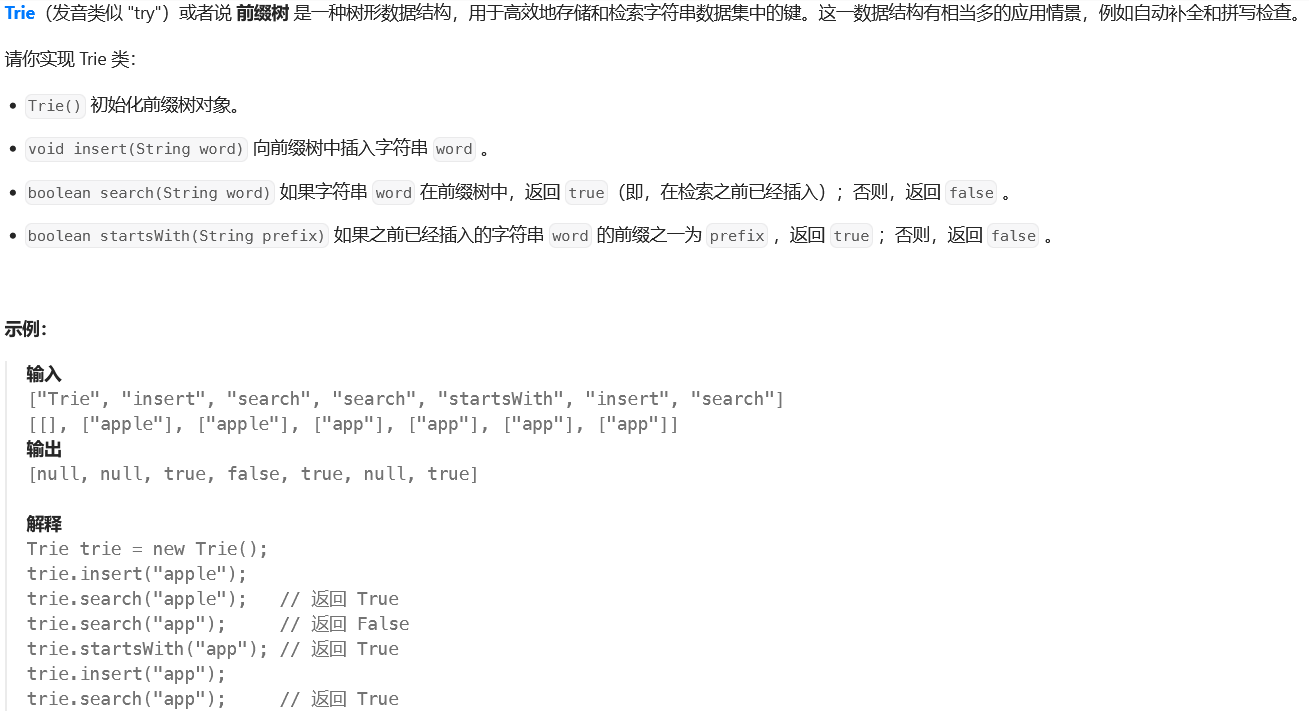

In [ ]:
# 树的每一个节点
class Node:
    def __init__(self):
        # 26个字母位置，初始都没有子节点
        self.children = [None] * 26
        self.is_end = False  # 是否是单词结尾

class Trie:
    def __init__(self):
        # 起点，空根节点
        self.root = Node()

    def insert(self, word: str) -> None:
        cur = self.root
        for char in word:
            # 把字母转成0~25下标 a=0,b=1...z=25
            idx = ord(char) - ord('a')
            # 没有这个分支就新建节点
            if not cur.children[idx]:
                cur.children[idx] = Node()
            # 往下走
            cur = cur.children[idx]
        # 单词最后一位，标记结束
        cur.is_end = True

    def search(self, word: str) -> bool:
        cur = self.root
        for char in word:
            idx = ord(char) - ord('a')
            # 中途断了，不存在这个单词
            if not cur.children[idx]:
                return False
            cur = cur.children[idx]
        # 字母全走完，必须是单词末尾才算存在
        return cur.is_end

    def startsWith(self, prefix: str) -> bool:
        cur = self.root
        for char in prefix:
            idx = ord(char) - ord('a')
            if not cur.children[idx]:
                return False
            cur = cur.children[idx]
        # 前缀走完就够，不用判断结尾
        return True